In [ ]:
!unzip /content/EuroSAT_RGB.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/EuroSAT_RGB/PermanentCrop/PermanentCrop_2494.jpg  
  inflating: /content/__MACOSX/EuroSAT_RGB/PermanentCrop/._PermanentCrop_2494.jpg  
  inflating: /content/EuroSAT_RGB/PermanentCrop/PermanentCrop_2480.jpg  
  inflating: /content/__MACOSX/EuroSAT_RGB/PermanentCrop/._PermanentCrop_2480.jpg  
  inflating: /content/EuroSAT_RGB/PermanentCrop/PermanentCrop_292.jpg  
  inflating: /content/__MACOSX/EuroSAT_RGB/PermanentCrop/._PermanentCrop_292.jpg  
  inflating: /content/EuroSAT_RGB/PermanentCrop/PermanentCrop_1189.jpg  
  inflating: /content/__MACOSX/EuroSAT_RGB/PermanentCrop/._PermanentCrop_1189.jpg  
  inflating: /content/EuroSAT_RGB/PermanentCrop/PermanentCrop_1837.jpg  
  inflating: /content/__MACOSX/EuroSAT_RGB/PermanentCrop/._PermanentCrop_1837.jpg  
  inflating: /content/EuroSAT_RGB/PermanentCrop/PermanentCrop_2496.jpg  
  inflating: /content/__MACOSX/EuroSAT_RGB/PermanentCrop/._PermanentCrop_2496.jpg  
  inflati

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

In [ ]:
# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
NUM_CLASSES = 10  # EuroSAT has 10 classes
IMAGE_SIZE = 64   # EuroSAT images are 64x64
TRAIN_VAL_SPLIT = 0.8  # 80% training, 20% validation
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# Data transformation - EuroSAT has RGB images
data_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load EuroSAT dataset (assumes you've downloaded it)
# If you don't have the dataset, use:
# !wget https://madm.dfki.de/files/sentinel/EuroSAT.zip
# !unzip EuroSAT.zip
data_dir = '/content/EuroSAT_RGB'  # Change this to your dataset path
if not os.path.exists(data_dir):
    print(f"Dataset not found at {data_dir}. Please download EuroSAT dataset first.")
    print("You can download it from: https://madm.dfki.de/files/sentinel/EuroSAT.zip")
    exit(1)

In [ ]:
#load the dataset
dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
class_names = dataset.classes
print(f"Classes: {class_names}")

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
# Split into training and validation sets
n_train = int(len(dataset) * TRAIN_VAL_SPLIT)
n_val = len(dataset) - n_train
train_dataset, val_dataset = random_split(dataset, [n_train, n_val])

In [ ]:
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")

Training images: 21600
Validation images: 5400


In [ ]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# Define the EfficientNet-B4 model
class EfficientNetB4(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetB4, self).__init__()
        # Load the model without pretrained weights (from scratch)
        self.model = efficientnet_b4(weights=None)

        # Replace classifier with a new one for our number of classes
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features=1792, out_features=num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
model = EfficientNetB4(NUM_CLASSES).to(DEVICE)

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
# Training and validation functions
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)

    epoch_loss = running_loss / processed_size
    epoch_acc = running_corrects.double() / processed_size

    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            processed_size += inputs.size(0)

    epoch_loss = running_loss / processed_size
    epoch_acc = running_corrects.double() / processed_size

    return epoch_loss, epoch_acc

In [ ]:
# Training loop
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Starting training for {NUM_EPOCHS} epochs...")

Starting training for 30 epochs...


In [ ]:
for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, DEVICE)

    # Update learning rate
    scheduler.step(val_loss)

    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - {epoch_time:.0f}s")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc
        }, 'efficientnet_b4_eurosat_best.pth')
        print(f"Saved new best model with validation accuracy: {val_acc:.4f}")



Validating: 100%|██████████| 169/169 [00:05<00:00, 28.75it/s]


Epoch 1/30 - 75s
Train Loss: 1.5366, Train Acc: 0.4281
Val Loss: 0.9978, Val Acc: 0.6535
Saved new best model with validation accuracy: 0.6535


Validating: 100%|██████████| 169/169 [00:06<00:00, 25.51it/s]


Epoch 2/30 - 70s
Train Loss: 0.9853, Train Acc: 0.6576
Val Loss: 0.6975, Val Acc: 0.7619
Saved new best model with validation accuracy: 0.7619


Validating: 100%|██████████| 169/169 [00:06<00:00, 25.72it/s]


...

Epoch 28/30 - 69s
Train Loss: 0.1409, Train Acc: 0.9535
Val Loss: 0.2142, Val Acc: 0.9350


Validating: 100%|██████████| 169/169 [00:05<00:00, 29.82it/s]


Epoch 29/30 - 68s
Train Loss: 0.1258, Train Acc: 0.9582
Val Loss: 0.1930, Val Acc: 0.9385


Validating: 100%|██████████| 169/169 [00:06<00:00, 25.89it/s]

Epoch 30/30 - 69s
Train Loss: 0.1800, Train Acc: 0.9384
Val Loss: 0.2168, Val Acc: 0.9309


In [ ]:
# Save final model
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc': val_acc
}, 'efficientnet_b4_eurosat_final.pth')


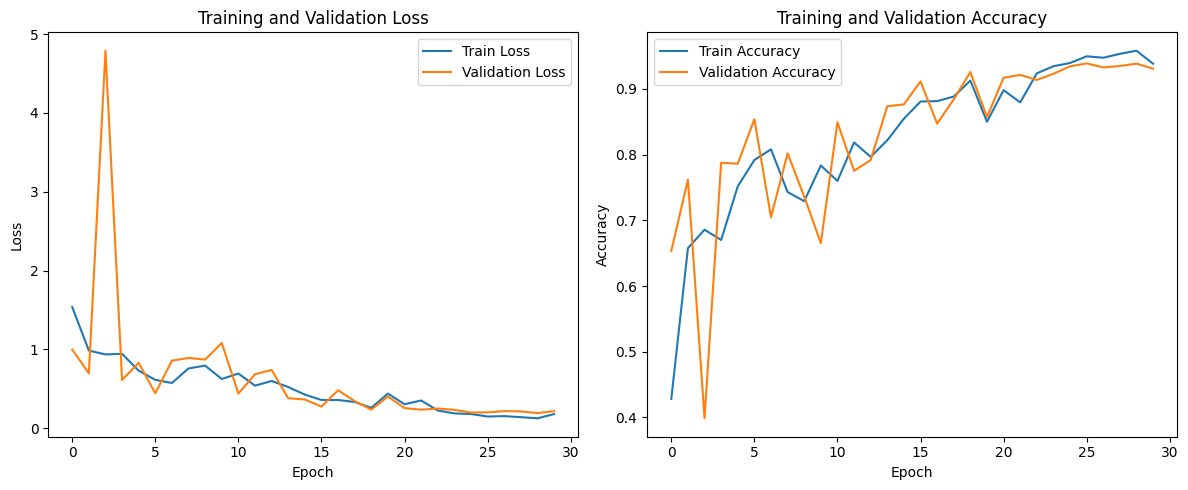

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.savefig('efficientnet_b4_eurosat_training_history.png')
plt.show()

In [ ]:
# Evaluate on the best model
print("Loading best model for final evaluation...")
checkpoint = torch.load('efficientnet_b4_eurosat_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
best_val_loss, best_val_acc = validate_epoch(model, val_loader, criterion, DEVICE)
print(f"Best model - Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}")


Loading best model for final evaluation...


Validating:   0%|          | 0/169 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Validating: 100%|██████████| 169/169 [00:09<00:00, 18.45it/s]

Best model - Val Loss: 0.2014, Val Acc: 0.9389


In [ ]:
# Optional: Generate confusion matrix
def generate_confusion_matrix(model, dataloader, class_names, device):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('efficientnet_b4_eurosat_confusion_matrix.png')
    plt.show()

    return cm

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


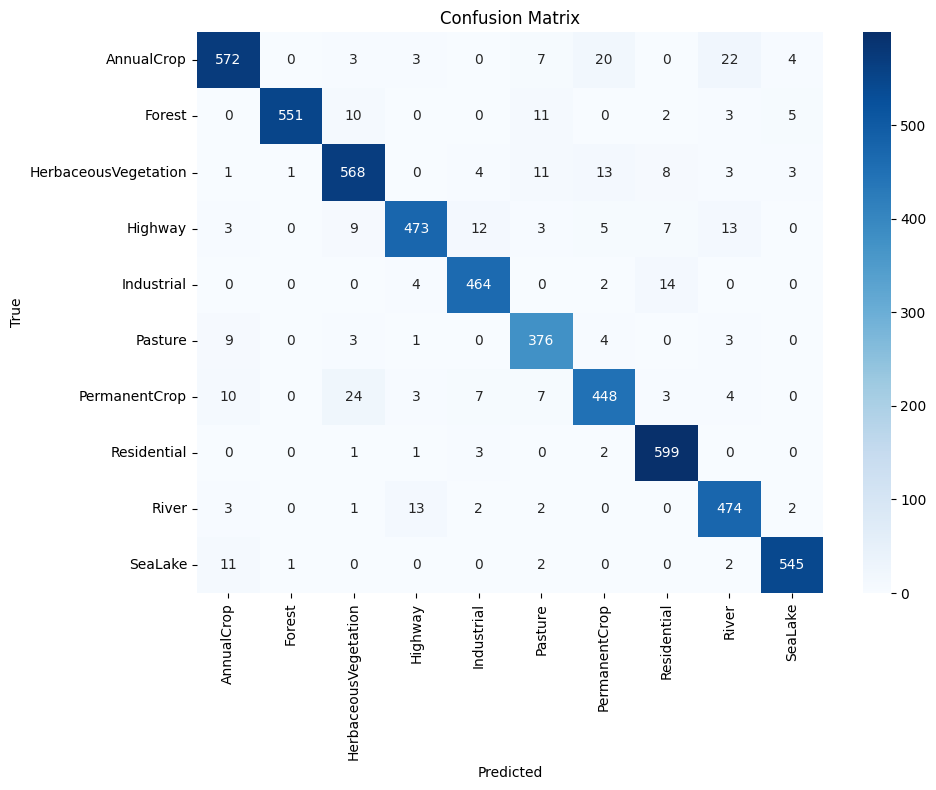

In [ ]:
try:
    import seaborn
    from sklearn.metrics import confusion_matrix
    generate_confusion_matrix(model, val_loader, class_names, DEVICE)
except ImportError:
    print("Skipping confusion matrix - missing dependencies")
